In [1]:
# Import libraries
import datetime as dt
import numpy as np
import PyIRI.main_library as ml
import PyIRTAM
import matplotlib.pyplot as plt
print('Modules imported')

Modules imported


In [2]:
# Specify a year, a month, a day, and a 15-min time window
year = 2018
month = 12
day = 15
hour = 20
minute = 0
# Specify array for decimal hour
ahr = np.array([hour + minute / 60.])
dtime = dt.datetime(year, month, day, hour, minute, 0)
time_stamp = dtime.strftime('%Y%m%d %H:%M')
print(dtime)
# Specify solar flux index F10.7 in SFU
f107 = 90.8

2018-12-15 20:00:00


In [3]:
# Create any horizontal grid (regular or irregular, global or regional).
# The grid arrays (alon and alat) should be flattened to be 1-D arrays.
# This is an example of a regular global grid
dlon = 2
dlat = 2
# Create 5x5 horizontal grid:
alon_2d, alat_2d = np.mgrid[-180:180 + dlon:dlon, -90:90 + dlat:dlat]
alon_1d = np.reshape(alon_2d, alon_2d.size)
alat_1d = np.reshape(alat_2d, alon_2d.size)
 
# Create height array. It can be regular or irregular.
# Here is an example for regularly spaced array
alt_res = 1
alt_min = 90
alt_max = 600
aalt = np.arange(alt_min, alt_max, alt_res)

In [4]:
 
# Run PyIRTAM for the selected time frame
# If irtam_dir='' in the inputs, the coefficients will be downloaded
print('Running PyIRTAM')
# Run PyIRTAM
(f2_iri, f1_iri, e_iri, es_iri, sun, mag, edp_iri, f2_irtam, f1_irtam,
e_irtam, es_irtam, edp_irtam) = PyIRTAM.run_PyIRTAM(year, month, day, ahr,
                                                    alon_1d, alat_1d, aalt, f107,
                                                    irtam_dir='',
                                                    use_subdirs=True,
                                                    download=True)
print('PyIRTAM run is completed')
print('Shape of Nm in f2_irtam is: ', f2_irtam['Nm'].shape)
 

Running PyIRTAM


IRTAM parameter coefficient file exists: /home/r01344106/anaconda3/lib/python3.11/site-packages/PyIRTAM/irtam_coeffs/2018/1215/IRTAM_B0in_COEFFS_20181215_200000.ASC
IRTAM parameter coefficient file exists: /home/r01344106/anaconda3/lib/python3.11/site-packages/PyIRTAM/irtam_coeffs/2018/1215/IRTAM_B1in_COEFFS_20181215_200000.ASC
IRTAM parameter coefficient file exists: /home/r01344106/anaconda3/lib/python3.11/site-packages/PyIRTAM/irtam_coeffs/2018/1215/IRTAM_hmF2_COEFFS_20181215_200000.ASC
IRTAM parameter coefficient file exists: /home/r01344106/anaconda3/lib/python3.11/site-packages/PyIRTAM/irtam_coeffs/2018/1215/IRTAM_foF2_COEFFS_20181215_200000.ASC


PyIRTAM run is completed
Shape of Nm in f2_irtam is:  (1, 16471)


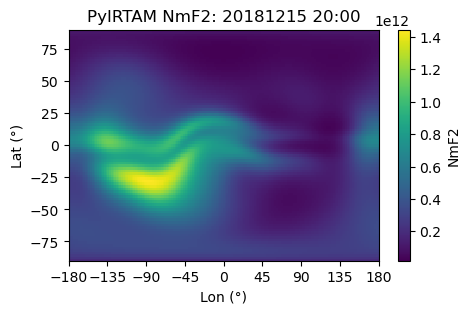

In [5]:
# Create a figure for NmF2 PyIRTAM
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True)
fig.set_size_inches(5, 3)
ax_plot = ax
ax_plot.set_title('PyIRTAM NmF2: ' + time_stamp)
cmap = 'plasma'
ax_plot.set_facecolor('lightgray')
ax_plot.set_ylabel('Lat (°)')
ax_plot.set_xlabel('Lon (°)')
ax_plot.set_ylim([-90, 90])
ax_plot.set_xlim([-180, 180])
ax_plot.set_xticks(np.arange(0, 24 + 4, 4))
ax_plot.set_xticks(np.arange(-180, 180 + 45, 45))
z = np.reshape(f2_irtam['Nm'], alon_2d.shape)
mesh = ax_plot.pcolormesh(alon_2d, alat_2d, z)
cbar = fig.colorbar(mesh, ax=ax_plot)
cbar.set_label('NmF2')

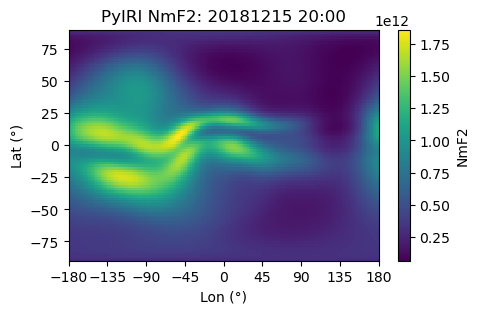

In [6]:
# Create a figure for NmF2 PyIRI
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True)
fig.set_size_inches(5, 3)
ax_plot = ax
ax_plot.set_title('PyIRI NmF2: ' + time_stamp)
cmap = 'plasma'
ax_plot.set_facecolor('lightgray')
ax_plot.set_ylabel('Lat (°)')
ax_plot.set_xlabel('Lon (°)')
ax_plot.set_ylim([-90, 90])
ax_plot.set_xlim([-180, 180])
ax_plot.set_xticks(np.arange(0, 24 + 4, 4))
ax_plot.set_xticks(np.arange(-180, 180 + 45, 45))
z = np.reshape(f2_iri['Nm'], alon_2d.shape)
mesh = ax_plot.pcolormesh(alon_2d, alat_2d, z)
cbar = fig.colorbar(mesh, ax=ax_plot)
cbar.set_label('NmF2')

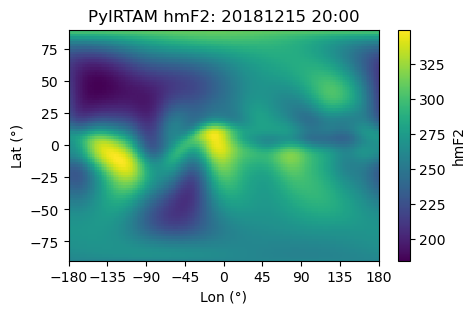

In [7]:
# Create a figure for hmF2 PyIRTAM
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True)
fig.set_size_inches(5, 3)
ax_plot = ax
ax_plot.set_title('PyIRTAM hmF2: ' + time_stamp)
cmap = 'plasma'
ax_plot.set_facecolor('lightgray')
ax_plot.set_ylabel('Lat (°)')
ax_plot.set_xlabel('Lon (°)')
ax_plot.set_ylim([-90, 90])
ax_plot.set_xlim([-180, 180])
ax_plot.set_xticks(np.arange(0, 24 + 4, 4))
ax_plot.set_xticks(np.arange(-180, 180 + 45, 45))
z = np.reshape(f2_irtam['hm'], alon_2d.shape)
mesh = ax_plot.pcolormesh(alon_2d, alat_2d, z)
cbar = fig.colorbar(mesh, ax=ax_plot)
cbar.set_label('hmF2')

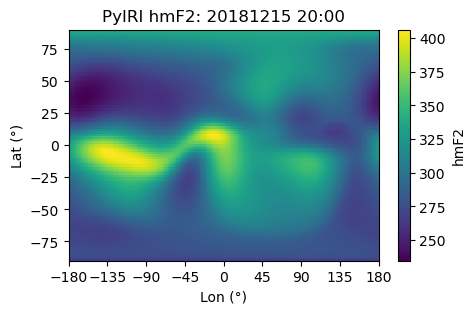

In [8]:
# Create a figure for hmF2 PyIRI
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True)
fig.set_size_inches(5, 3)
ax_plot = ax
ax_plot.set_title('PyIRI hmF2: ' + time_stamp)
cmap = 'plasma'
ax_plot.set_facecolor('lightgray')
ax_plot.set_ylabel('Lat (°)')
ax_plot.set_xlabel('Lon (°)')
ax_plot.set_ylim([-90, 90])
ax_plot.set_xlim([-180, 180])
ax_plot.set_xticks(np.arange(0, 24 + 4, 4))
ax_plot.set_xticks(np.arange(-180, 180 + 45, 45))
z = np.reshape(f2_iri['hm'], alon_2d.shape)
mesh = ax_plot.pcolormesh(alon_2d, alat_2d, z)
cbar = fig.colorbar(mesh, ax=ax_plot)
cbar.set_label('hmF2')

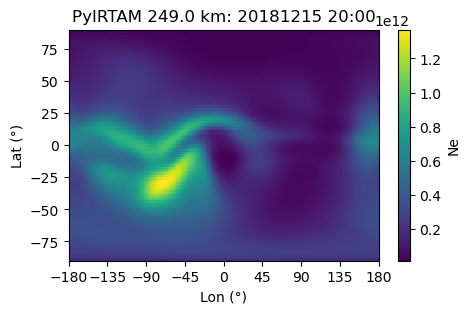

In [9]:
plot_alt = 249.
# Create a figure for hmF2 PyIRTAM
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True)
fig.set_size_inches(5, 3)
ax_plot = ax
ax_plot.set_title('PyIRTAM ' + str(plot_alt) + ' km: ' + time_stamp)
cmap = 'plasma'
ax_plot.set_facecolor('lightgray')
ax_plot.set_ylabel('Lat (°)')
ax_plot.set_xlabel('Lon (°)')
ax_plot.set_ylim([-90, 90])
ax_plot.set_xlim([-180, 180])
ax_plot.set_xticks(np.arange(0, 24 + 4, 4))
ax_plot.set_xticks(np.arange(-180, 180 + 45, 45))
ind_h = np.where(aalt == plot_alt)[0]
z = np.reshape(edp_irtam[0, ind_h, :], alon_2d.shape)
mesh = ax_plot.pcolormesh(alon_2d, alat_2d, z)
cbar = fig.colorbar(mesh, ax=ax_plot)
cbar.set_label('Ne')

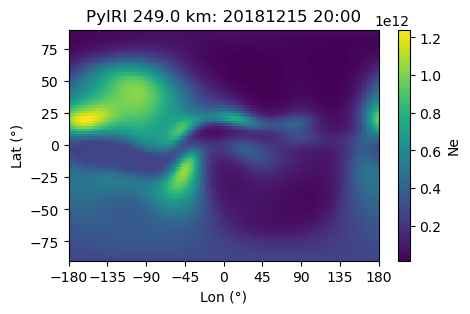

In [10]:
# Create a figure for hmF2 PyIRI
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True)
fig.set_size_inches(5, 3)
ax_plot = ax
ax_plot.set_title('PyIRI ' + str(plot_alt) + ' km: ' + time_stamp)
cmap = 'plasma'
ax_plot.set_facecolor('lightgray')
ax_plot.set_ylabel('Lat (°)')
ax_plot.set_xlabel('Lon (°)')
ax_plot.set_ylim([-90, 90])
ax_plot.set_xlim([-180, 180])
ax_plot.set_xticks(np.arange(0, 24 + 4, 4))
ax_plot.set_xticks(np.arange(-180, 180 + 45, 45))
z = np.reshape(edp_iri[0, ind_h, :], alon_2d.shape)
mesh = ax_plot.pcolormesh(alon_2d, alat_2d, z)
cbar = fig.colorbar(mesh, ax=ax_plot)
cbar.set_label('Ne')